# Unidad 3 - Tema 1 - Semana 2  
## Proyecto práctico: Sistema inteligente para predecir intención de compra con FLAML
## Integrantes: Anahí Zúñiga, Ariel Jiménez, Jeanpiere García, Christian Correa.

**Asignatura:** Fundamentos de Ciencia de Datos e Inteligencia Artificial  
**Unidad 3:** Sistemas de Información Inteligentes para la toma de decisiones  
**Tema:** Fundamentos de Sistemas de Información Inteligentes  
**Subtemas:**  
- Técnicas de Aprendizaje Automático Aplicadas  
- Interconexión y Comunicación  

---

### Propósito de la práctica

En este notebook construiremos un prototipo de sistema inteligente que predice si una sesión de navegación en una tienda online terminará en compra.

El proyecto sigue el flujo:

**Datos → Modelo AutoML → Predicción → Comunicación del resultado → Decisión humana**

Usaremos **FLAML**, una herramienta AutoML low-code que permite entrenar y comparar modelos con pocas instrucciones.



# 1. Contexto del problema

Una tienda online recibe muchas visitas. Algunas personas revisan productos y compran, mientras que otras abandonan la página sin realizar ninguna compra.

La empresa desea responder la siguiente pregunta:

> ¿Podemos predecir si una sesión de navegación terminará en compra?
* Sí, es posible. Desde la perspectiva de la Ciencia de Datos, la intención de compra no se asume como un acto de azar, sino como la consecuencia de un patrón conductual medible. A través de la captura de metadatos de sesión, como el tiempo de retención, la profundidad de exploración de los catálogos y la resistencia al rebote, un algoritmo de Machine Learning puede encontrar la frontera matemática que separa a un visitante casual de un cliente decidido. El objetivo de este proyecto es demostrar que, procesando el historial de navegación adecuado, podemos transformar la incertidumbre del tráfico web en una probabilidad de conversión calculable en tiempo real.

Este tipo de sistema puede apoyar decisiones como:

- mostrar promociones personalizadas;
- activar ayuda por chat;
- recomendar productos relacionados;
- identificar páginas donde los usuarios abandonan el sitio;
- mejorar la experiencia de navegación.



# 2. Dataset

Usaremos el dataset **Online Shoppers Purchasing Intention Dataset** del repositorio UCI Machine Learning Repository.

La variable objetivo será:

**Revenue**

Significado:

- `True`: la sesión terminó en compra.
- `False`: la sesión no terminó en compra.

Por tanto, este es un problema de **clasificación binaria**.



# 3. Instalación de librerías

Ejecuta la siguiente celda en Google Colab.

> Si Colab solicita reiniciar el entorno después de instalar, acepta el reinicio y vuelve a ejecutar las celdas desde esta sección.


In [1]:
# !pip install -q "flaml[automl]"


# 4. Importar librerías

Importamos las librerías principales para:

- cargar datos;
- preparar variables;
- entrenar el modelo AutoML;
- evaluar resultados;
- visualizar métricas.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from flaml import AutoML

print("Librerías cargadas correctamente")

Librerías cargadas correctamente



# 5. Cargar el dataset desde internet

Cargaremos el archivo CSV directamente desde el repositorio de UCI.


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"

df = pd.read_csv(url)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



# 6. Exploración inicial

Primero revisamos el tamaño del dataset.


In [4]:
df.shape

(12330, 18)


**Pregunta para responder:**

¿Cuántas filas y cuántas columnas tiene el dataset?


* El dataset tiene exactamente 12,330 filas (entradas o registros de sesiones de navegación) y 18 columnas (variables o características medidas por cada usuario).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           


# 7. Revisar columnas del dataset


In [6]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')


Algunas variables importantes son:

- `ProductRelated`: número de páginas de productos visitadas.
- `ProductRelated_Duration`: tiempo en páginas de productos.
- `BounceRates`: tasa de rebote.
- `ExitRates`: tasa de salida.
- `PageValues`: valor promedio de la página.
- `VisitorType`: tipo de visitante.
- `Weekend`: si la visita ocurrió en fin de semana.
- `Revenue`: variable objetivo, indica si hubo compra o no.



# 8. Analizar la variable objetivo

Revisamos cuántas sesiones terminaron en compra y cuántas no.


In [7]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [8]:
df["Revenue"].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


**Preguntas para responder:**

1. ¿Qué porcentaje de sesiones terminó en compra?
* El 15.47 % de las sesiones terminó en una compra real (True: 1,908 sesiones), mientras que el 84.53 % de las visitas no terminó en compra (False: 10,422 sesiones).
2. ¿El dataset está balanceado o desbalanceado?
* El dataset está altamente desbalanceado. Existe una asimetría extrema donde la clase mayoritaria ("No compra") domina casi el 85 % de los datos, mientras que la clase de interés ("Compra") representa apenas un 15.5 %.
3. ¿Por qué puede ser importante revisar esto antes de entrenar el modelo?
* Es fundamental porque los algoritmos de Machine Learning tienden a sesgarse hacia la clase mayoritaria cuando existe un desbalance severo. Si un modelo decide predecir que "nadie compra" (predecir siempre False), obtendría una exactitud (accuracy) del 84.53 % de forma automática sin haber aprendido a identificar los verdaderos patrones de intención de compra. Saber esto nos obliga a tomar medidas preventivas, como realizar una división estratificada de los datos (stratify=y) y evaluar el rendimiento utilizando métricas más confiables para estos casos, como el F1-Score y el ROC-AUC en lugar de mirar únicamente la exactitud global.


# 9. Comparar comportamiento de compra y no compra

Revisamos algunos promedios agrupados por la variable `Revenue`.


In [9]:
variables_interes = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

df.groupby("Revenue")[variables_interes].mean()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
Revenue,,,,,
False,28.714642,1069.987809,0.025317,0.047378,1.975998
True,48.210168,1876.209615,0.005117,0.019555,27.264518


**Pregunta para responder:**

¿Qué diferencias observas entre las sesiones que terminaron en compra y las que no terminaron en compra?
Se observan diferencias conductuales muy contundentes en las medias de navegación de ambos grupos:

* Volumen de exploración (ProductRelated): Los usuarios que compran visitan en promedio 48.21 páginas de productos, frente a las 28.71 páginas que revisan quienes abandonan la tienda sin comprar.

* Tiempo de retención (ProductRelated_Duration): Quienes terminan comprando dedican un promedio de 1,876.21 segundos (unos 31 minutos) viendo productos, lo cual supera por mucho a los 1,069.99 segundos (aprox. 17.8 minutos) de los visitantes que no compran.

* Tasas de abandono (BounceRates y ExitRates): Las sesiones sin compra presentan una tasa de rebote (0.025) y una tasa de salida (0.047) notablemente superiores a las sesiones con compra (0.005 y 0.019 respectivamente). Esto demuestra que el cliente comprador navega con un objetivo claro y se sale menos de las páginas de destino.

* Indicador de valor (PageValues): Es el diferenciador más dramático; las páginas web visitadas por usuarios que acaban comprando tienen un valor promedio de 27.26, mientras que en las sesiones infructuosas el valor promedio de la página cae a 1.98.


# 10. Preparación de datos

FLAML puede trabajar con datos de `pandas`, pero para evitar problemas con variables categóricas en diferentes entornos, convertiremos las variables de texto en variables numéricas mediante `get_dummies`.

También convertiremos la variable objetivo `Revenue` a valores numéricos:

- `True` → 1
- `False` → 0


In [10]:
# Separar variables predictoras y variable objetivo
X_original = df.drop("Revenue", axis=1)
y = df["Revenue"].astype(int)

# Convertir variables categóricas a variables numéricas
X = pd.get_dummies(X_original, drop_first=False)

print("Columnas originales:", X_original.shape[1])
print("Columnas después de get_dummies:", X.shape[1])

X.head()

Columnas originales: 17
Columnas después de get_dummies: 28


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True



# 11. Separar datos de entrenamiento y prueba

Usaremos:

- 80 % de los datos para entrenamiento.
- 20 % de los datos para prueba.

El parámetro `stratify=y` ayuda a mantener proporciones similares de compra/no compra en ambos conjuntos.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (9864, 28)
Prueba: (2466, 28)



# 12. Entrenar modelo AutoML con FLAML

FLAML buscará automáticamente un buen modelo para este problema de clasificación.

El parámetro `time_budget` indica cuántos segundos tendrá FLAML para buscar modelos.

Para clase puedes usar:

- `time_budget = 30` si quieres que sea rápido;
- `time_budget = 60` para una búsqueda un poco mejor;
- `time_budget = 120` si tienes más tiempo.


In [12]:
automl = AutoML()

automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="classification",
    metric="accuracy",
    time_budget=60,
    seed=123
)

[flaml.automl.logger: 06-22 19:23:59] {2375} INFO - task = classification
[flaml.automl.logger: 06-22 19:23:59] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 06-22 19:23:59] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 06-22 19:23:59] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 06-22 19:23:59] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 06-22 19:23:59] {3046} INFO - Estimated sufficient time budget=1366s. Estimated necessary time budget=32s.
[flaml.automl.logger: 06-22 19:23:59] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.5502e-01,	best estimator lgbm's best error=1.5502e-01
[flaml.automl.logger: 06-22 19:23:59] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-22 19:23:59] {3097} INFO -  at 0.6s,	estimator lgbm's best error=1.1044e-01,	best estimator lgbm's best error=1.1044e-01
[flaml


# 13. Revisar el mejor modelo encontrado

Después del entrenamiento, FLAML indica cuál fue el mejor estimador encontrado.


In [13]:
print("Mejor modelo encontrado:")
print(automl.best_estimator)

print("\nMejor configuración:")
print(automl.best_config)

print("\nMejor pérdida interna:")
print(automl.best_loss)

Mejor modelo encontrado:
xgboost

Mejor configuración:
{'n_estimators': 12, 'max_leaves': 13, 'min_child_weight': np.float64(0.18266249996502282), 'learning_rate': np.float64(0.25062062529322227), 'subsample': np.float64(0.9069308056914804), 'colsample_bylevel': 1.0, 'colsample_bytree': np.float64(0.9372186384657905), 'reg_alpha': np.float64(0.000981737970472071), 'reg_lambda': np.float64(1.636582163354423)}

Mejor pérdida interna:
0.09118541033434646


**Pregunta para responder:**

¿Qué modelo seleccionó FLAML como mejor modelo?
* FLAML seleccionó como mejor estimador un modelo de XGBoost (XGBClassifier). Tras evaluar varios algoritmos, determinó que este modelo basado en árboles de decisión con Gradient Boosting lograba minimizar la métrica de error (1 - Accuracy), alcanzando una pérdida interna de 0.0911 (lo que equivale a una exactitud del 90.88 % en los datos de validación interna). Para lograr este rendimiento, el AutoML optimizó sus hiperparámetros construyendo 12 árboles (n_estimators: 12), un máximo de 13 hojas por árbol (max_leaves: 13) y una tasa de aprendizaje (learning_rate) de 0.25.


# 14. Realizar predicciones en el conjunto de prueba


In [14]:
y_pred = automl.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1])


# 15. Evaluar el modelo

Calculamos métricas principales:

- Accuracy: proporción total de aciertos.
- Precision: de los casos que el modelo predijo como compra, cuántos realmente fueron compra.
- Recall: de los compradores reales, cuántos detectó el modelo.
- F1-score: balance entre precision y recall.


In [15]:
metricas = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}

pd.DataFrame(metricas, index=["Modelo FLAML"]).T

,Modelo FLAML
Accuracy,0.915653
Precision,0.766871
Recall,0.654450
F1-score,0.706215


In [16]:
print(classification_report(y_test, y_pred, target_names=["No compra", "Compra"]))

              precision    recall  f1-score   support

   No compra       0.94      0.96      0.95      2084
      Compra       0.77      0.65      0.71       382

    accuracy                           0.92      2466
   macro avg       0.85      0.81      0.83      2466
weighted avg       0.91      0.92      0.91      2466




# 16. Matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo.

Interpretación:

- Verdadero negativo: el usuario no compró y el modelo predijo no compra.
- Verdadero positivo: el usuario compró y el modelo predijo compra.
- Falso positivo: el modelo predijo compra, pero el usuario no compró.
- Falso negativo: el modelo predijo no compra, pero el usuario sí compró.


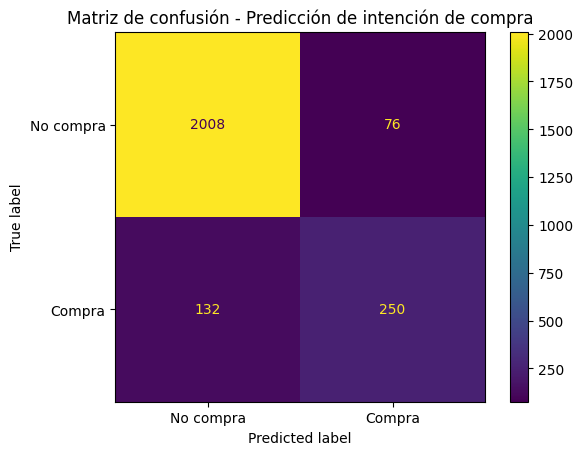

In [17]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No compra", "Compra"]
)

disp.plot()
plt.title("Matriz de confusión - Predicción de intención de compra")
plt.show()

**Preguntas para responder:**

1. ¿Qué error sería más grave para una tienda online: un falso positivo o un falso negativo?

* Dependiendo de la estrategia de negocio, el error habitualmente más grave y costoso en comercio electrónico es el Falso Negativo (predecir "No compra" cuando el cliente en realidad "Sí quería comprar").

    * Por qué el Falso Negativo es peor: Si el sistema predice que el usuario va a abandonar la tienda, no se activa ninguna acción preventiva (como ofrecerle un cupón de 10% de descuento de última hora, envío gratis o desplegar el chat de asistencia). Al no retenerlo, se pierde una venta real y directa. Es un alto costo de oportunidad.

    * Por qué el Falso Positivo es menos grave: Si el modelo se equivoca y etiqueta como "comprador" a alguien que solo está vitrineando, el único impacto es que se le mostrará una recomendación o una oferta que terminará ignorando. El costo de desplegar un banner o enviar un correo automático es prácticamente cero.

2. ¿Por qué no deberíamos fijarnos solo en el Accuracy?
* No debemos confiar únicamente en el Accuracy (Exactitud global) porque en datasets fuertemente desbalanceados es una métrica engañosa. Sabiendo que el 84.5 % de las visitas no termina en compra, un modelo "inútil" que siempre prediga "No compra" obtendría un 84.5 % de Accuracy de forma automática, sin haber identificado a un solo comprador. Por ello, debemos analizar el reporte de clasificación:

    * Precision (Precisión - 76.68 %): Mide la calidad de las alarmas del modelo. De todas las sesiones que el modelo etiquetó con intención de "Compra", el 76.68 % realmente terminó pagando (hubo 76 falsas alarmas).

    * Recall (Sensibilidad o Cobertura - 65.45 %): Mide la capacidad de detección. Del total de 382 compradores reales que entraron a la tienda, el modelo logró capturar a 250 (el 65.45 %) y dejó escapar a 132.

    * F1-Score (70.62 %): Es la media armónica entre Precision y Recall. Es la métrica clave para este proyecto, ya que castiga los desequilibrios y nos muestra en un solo porcentaje el balance real entre no dar falsas alarmas y no dejar escapar clientes.  
3. ¿El modelo detecta bien a los usuarios que compran?
Como está desbalanceado, si hay falsos + y - que `pueden interferir en las predicciones.

* El modelo tiene un desempeño confiable y seguro, pero con un margen de mejora importante en la captura total de compradores.

* Su gran fortaleza es la Precisión (76.68 %): cuando el algoritmo asegura que un cliente va a comprar, acierta 3 de cada 4 veces. Esto es excelente para no desperdiciar dinero en promociones masivas. Sin embargo, su punto débil es el Recall (65.45 %): se le están escapando el 34.5 % de los compradores reales (132 Falsos Negativos). Esto demuestra el peso del desbalance de clases; el algoritmo se ha vuelto algo "conservador" y prefiere asegurar el pronóstico de la clase mayoritaria antes que arriesgarse a disparar alertas de compra para todos los usuarios.


# 17. Probabilidades de predicción

Si el modelo lo permite, podemos obtener la probabilidad de compra.


In [18]:
try:
    y_proba = automl.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", auc)
except Exception as e:
    print("Este modelo no permitió calcular probabilidades directamente.")
    print(e)

ROC-AUC: 0.932758689994071



# 18. Predicción de nuevas sesiones

Simularemos nuevas sesiones tomando 5 registros del conjunto de prueba.

En un sistema real, estos datos vendrían de la tienda online, una base de datos, una API o un sistema de analítica web.


In [19]:
# Tomar 5 sesiones de prueba
muestra_indices = X_test.sample(5).index

nuevas_sesiones_modelo = X_test.loc[muestra_indices]
nuevas_sesiones_original = X_original.loc[muestra_indices]

# Realizar predicción
predicciones = automl.predict(nuevas_sesiones_modelo)

# Intentar obtener probabilidad de compra
try:
    probabilidades = automl.predict_proba(nuevas_sesiones_modelo)[:, 1]
except Exception:
    probabilidades = [np.nan] * len(predicciones)

resultado = nuevas_sesiones_original.copy()
resultado["prediccion_compra"] = predicciones
resultado["probabilidad_compra"] = probabilidades

resultado[[
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues",
    "VisitorType",
    "Weekend",
    "prediccion_compra",
    "probabilidad_compra"
]]

,ProductRelated,ProductRelated_Duration,PageValues,VisitorType,Weekend,prediccion_compra,probabilidad_compra
6568,51,2921.902778,8.339172,Returning_Visitor,True,0,0.274410
1370,6,25.500000,0.000000,Returning_Visitor,False,0,0.021570
10208,78,4716.572619,0.000000,Returning_Visitor,True,0,0.072020
10544,38,1787.395833,0.000000,New_Visitor,False,0,0.129553
740,59,2816.781781,2.346800,Returning_Visitor,False,0,0.454810



# 19. Convertir la predicción en una decisión

Un sistema inteligente no debe quedarse solo en la predicción.  
Debe comunicar un resultado útil para apoyar la toma de decisiones.


In [20]:
def accion_recomendada(fila):
    if fila["prediccion_compra"] == 1:
        return "Alta intención de compra: mostrar promoción, recomendación personalizada o activar chat de ayuda."
    else:
        return "Baja intención de compra: revisar experiencia de navegación o mantener monitoreo."

resultado["accion_recomendada"] = resultado.apply(accion_recomendada, axis=1)

resultado_final = resultado[[
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues",
    "VisitorType",
    "Weekend",
    "prediccion_compra",
    "probabilidad_compra",
    "accion_recomendada"
]]

resultado_final

,ProductRelated,ProductRelated_Duration,PageValues,VisitorType,Weekend,prediccion_compra,probabilidad_compra,accion_recomendada
6568,51,2921.902778,8.339172,Returning_Visitor,True,0,0.274410,Baja intención de compra: revisar experiencia ...
1370,6,25.500000,0.000000,Returning_Visitor,False,0,0.021570,Baja intención de compra: revisar experiencia ...
10208,78,4716.572619,0.000000,Returning_Visitor,True,0,0.072020,Baja intención de compra: revisar experiencia ...
10544,38,1787.395833,0.000000,New_Visitor,False,0,0.129553,Baja intención de compra: revisar experiencia ...
740,59,2816.781781,2.346800,Returning_Visitor,False,0,0.454810,Baja intención de compra: revisar experiencia ...



# 20. Crear una vista tipo reporte

Esta tabla puede entenderse como una salida simple para un dashboard o reporte gerencial.


In [21]:
reporte = resultado_final.copy()

reporte["prediccion_compra"] = reporte["prediccion_compra"].map({
    1: "Compra probable",
    0: "Compra no probable"
})

reporte

,ProductRelated,ProductRelated_Duration,PageValues,VisitorType,Weekend,prediccion_compra,probabilidad_compra,accion_recomendada
6568,51,2921.902778,8.339172,Returning_Visitor,True,Compra no probable,0.274410,Baja intención de compra: revisar experiencia ...
1370,6,25.500000,0.000000,Returning_Visitor,False,Compra no probable,0.021570,Baja intención de compra: revisar experiencia ...
10208,78,4716.572619,0.000000,Returning_Visitor,True,Compra no probable,0.072020,Baja intención de compra: revisar experiencia ...
10544,38,1787.395833,0.000000,New_Visitor,False,Compra no probable,0.129553,Baja intención de compra: revisar experiencia ...
740,59,2816.781781,2.346800,Returning_Visitor,False,Compra no probable,0.454810,Baja intención de compra: revisar experiencia ...



# 21. Interconexión y comunicación

En un sistema real, el flujo sería:

```text
Tienda online
    ↓
Datos de navegación
    ↓
Modelo de machine learning
    ↓
Predicción de intención de compra
    ↓
Dashboard, alerta o recomendación
    ↓
Decisión empresarial
```

El modelo podría conectarse con:

- una página web;
- una base de datos de clientes;
- un dashboard;
- una plataforma de marketing;
- un sistema de correo electrónico;
- un sistema de recomendaciones.



# 22. Guardar el modelo entrenado

Podemos guardar el objeto `automl` para reutilizarlo posteriormente.

En un sistema real, este modelo podría cargarse desde una aplicación web o un servicio de predicción.


In [22]:
# import pickle

# nombre_modelo = "modelo_flaml_intencion_compra.pkl"

# with open(nombre_modelo, "wb") as archivo:
#     pickle.dump(automl, archivo)

# print("Modelo guardado como:", nombre_modelo)


# 23. Cargar el modelo guardado

Esta celda muestra cómo recuperar el modelo.


In [23]:
# with open("modelo_flaml_intencion_compra.pkl", "rb") as archivo:
#     modelo_cargado = pickle.load(archivo)

# prediccion_prueba = modelo_cargado.predict(nuevas_sesiones_modelo)

# prediccion_prueba